<a href="https://colab.research.google.com/github/yuki-hogehoge/dm-skincare-analysis/blob/main/analysis_B_fragrance_alcohol_rating/analysis_B_fragrance_alcohol_rating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 分析B: 香料・アルコール系溶媒の有無と rating の関係

dm.de の Serum & Kur カテゴリ(スキンケア美容液)について、**香料(Parfum)** と **アルコール系溶媒(Alcohol denat.)** の有無が、ユーザー評価(rating)と関連するかを調べる。

- 手法: レビュー数で縮小したベイズ平均 + Mann-Whitney U検定 + 共通言語効果量(AUC)
- 信頼区間: ブランド単位のクラスタ・ブートストラップ(同じブランドの商品は独立でないため)
- 共通関数: `common/stats_utils.py`(`auc_xy` / `make_auc_func` / `bayes_avg` / `run_test` / `cluster_boot`)

## 結論(先出し)

1. **香料**: 検討した全設定で、rating との関連は見えなかった(主分析 AUC 0.556 [0.42, 0.69]、ブランド内比較 0.521)。「差がない」ではなく「**差があるという証拠は得られなかった**」。
2. **アルコール系溶媒**: 単純比較では「入っているほうがやや高い」(AUC 0.57〜0.66)。ただし
   - CI下限が 0.5 の境界上にあり、乱数や設定で上下する
   - アルコール入り34件のうち29件が、L'ORÉAL・WELEDA・NIVEA・lavera・GARNIER の5ブランドに集中
   - 大手3ブランドを除くと消え、ブランド内比較でも消える
   
   → **成分そのものの効果を示す証拠は得られなかった**。大手ブランドの商品が高評価・レビュー多数になりやすいことで説明できる。
3. 因果ではなく関連の話であり、ブランド内比較・大手除外の比較は検出力が低い。

## 1. データ準備

### 1-1. 読み込み

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys

# ↓ common/ フォルダとCSVを置いた、Googleドライブ上のフォルダに書き換える
PROJECT_DIR = "/content/drive/MyDrive/Colab Notebooks/German_Skincare_Data_Analysis"

os.chdir(PROJECT_DIR)          # 作業ディレクトリを移動(CSVや図の保存先もここになる)
sys.path.insert(0, PROJECT_DIR)  # `from common.stats_utils import ...` が通るようにする

print(os.listdir(PROJECT_DIR))   # common / skincare_dataset_final.csv が見えればOK

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['00_project', '01_raw_data', '02_clean_data', '03_notebooks', 'ingredient_concern_heatmap.png', 'dm_serum_top30_working.csv', 'alcohol_robustness_forest.png', 'common']


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from common.stats_utils import auc_xy, bayes_avg, run_test

pd.set_option("display.width", 200)
DATA_PATH = "02_clean_data/skincare_dataset_final.csv"

df = pd.read_csv(DATA_PATH)
print("形状:", df.shape)
print("欠損数:")
print(df[["rating_value", "rating_count", "fragrance_present", "alcohol_denat_present"]].isna().sum().to_string())

形状: (172, 49)
欠損数:
rating_value             0
rating_count             0
fragrance_present        0
alcohol_denat_present    0


### 1-2. 成分フラグの検証(アルコール)

分析Aで「パース処理のバグ」が見つかったため、検定の前に判定ロジックを疑う。
`alcohol_denat_present` が何を拾っているかを、成分リストから調べ直した。

発見: `alcohol* denat`、`alcohol¹ denat`(脚注記号付き)や `SD Alcohol 40-B`(別名)が取りこぼされていた。
脚注記号を除去したうえで判定し直した `alcohol_v2` を作る(元のフラグは残す)。
`startswith` にしているのは、`cetyl alcohol` など別成分を巻き込まないため。

In [ ]:
# 成分リストを「小文字・前後空白除去済みのリスト」に変換
df["ing_list"] = (
    df["ingredients_list_str"].fillna("")
      .str.split(";")
      .apply(lambda xs: [x.strip().lower() for x in xs if x.strip()])
)

def norm_token(t):
    # 脚注記号(*、上付き数字など)を除去して正規化
    t = re.sub(r"[\*\u00b9\u00b2\u00b3\u2070-\u2079]", "", t)
    return re.sub(r"\s+", " ", t).strip()

def has_alcohol_denat_v2(lst):
    return int(any(norm_token(t).startswith(("alcohol denat", "sd alcohol")) for t in lst))

df["alcohol_v2"] = df["ing_list"].apply(has_alcohol_denat_v2)

print("元フラグ(行) × v2(列):")
print(pd.crosstab(df["alcohol_denat_present"], df["alcohol_v2"]))
print("\n0→1 に変わった商品:")
changed = df[df["alcohol_denat_present"] != df["alcohol_v2"]]
for i, r in changed.iterrows():
    hit = [t for t in r["ing_list"] if "alcohol" in t and ("denat" in t or "sd" in t)]
    print(i, r["brand"], "|", r["name"][:40], "|", hit)

元フラグ(行) × v2(列):
alcohol_v2               0   1
alcohol_denat_present         
0                      138   5
1                        0  29

0→1 に変わった商品:
28 Balea | Gesichtsserum Beauty Hyaluron 7-fach, 30 | ['sd alcohol 40-b']
37 lavera NATURKOSMETIK | Serum Glow by Nature Vitamin C Boost, 30 | ['alcohol* denat']
65 lavera NATURKOSMETIK | Zellschutz-Serum Skin Longevity, 30 ml | ['alcohol* denat']
111 alverde NATURKOSMETIK | Pigmentfleckenserum Vital, 30 ml | ['alcohol¹ denat']
138 lavera NATURKOSMETIK | Serum Hydro Refresh, 30 ml | ['alcohol* denat']


### 1-3. 成分フラグの検証(香料)と、分析Aへの波及チェック

- 「香料なし」判定なのに、EU表示義務のある香料アレルゲンを含む商品を探す(頑健性チェック用の代替定義 `fragrance_alt` に使う)
- 分析Aの成分に、脚注記号付きの表記ゆれがないか確認する

In [ ]:
allergens = ["linalool", "limonene", "citronellol", "geraniol", "citral",
             "coumarin", "eugenol", "benzyl salicylate", "hexyl cinnamal",
             "benzyl benzoate", "farnesol", "isoeugenol", "hydroxycitronellal",
             "amyl cinnamal", "butylphenyl methylpropional"]
hits = df[df["fragrance_present"] == 0].copy()
hits["allergens_found"] = hits["ing_list"].apply(lambda lst: [t for t in lst if any(a in t for a in allergens)])
hits = hits[hits["allergens_found"].str.len() > 0]
alt_idx = list(hits.index)
print("香料なし判定だがアレルゲンを含む商品:", len(hits), "件, index =", alt_idx)
print(hits[["brand", "name"]].to_string())

print("\n--- 分析Aの成分: 記号付き表記の有無 ---")
for k in ["niacinamide", "glycerin", "hyaluron", "retinol", "retinal", "ascorb", "vitamin c", "tocopher"]:
    variants = {}
    for lst in df["ing_list"]:
        for t in lst:
            if k in t:
                variants[t] = variants.get(t, 0) + 1
    odd = {t: n for t, n in variants.items() if any(not (ch.isalnum() or ch in " -,()/.") for ch in t)}
    print(k, "→", odd if odd else "なし")

香料なし判定だがアレルゲンを含む商品: 4 件, index = [73, 92, 100, 108]
                   brand                                   name
73          NØ cosmetics           Serum Pore Minimizing, 20 ml
92              Diaderma  Gesichtsöl Karotten-Öl mit Q10, 30 ml
100            Schaebens     Konzentrat Perfect Skin Glow, 7 St
108  Australian BodyCare   Anti Pickel Serum Niacinamide, 30 ml

--- 分析Aの成分: 記号付き表記の有無 ---
niacinamide → なし
glycerin → なし
hyaluron → なし
retinol → なし
retinal → なし
ascorb → なし
vitamin c → なし
tocopher → なし


### 1-4. 分析対象の確定・ブランド名の統一・フラグの作成

**除外ルール**
- `rating_count == 0` の4件: rating_value が欠損ではなく 0.0 で入っており、残すと最低評価として扱われてしまう
- `ingredients_multi_variant_flag == True` の1件: 成分表が複数バリアント分混ざっており、フラグが信頼できない(分析Aの除外と同じ1件)

**ブランド名の統一**: 同じ会社の別表記が別クラスタ扱いになると、ブートストラップCIが実態より狭くなる。
`Diaderma` と `Diadermine` は別会社なので統一しない。

**フラグ**
- 主分析: `fragrance_main`(元のフラグ)、`alcohol_main`(= `alcohol_v2`)
- 頑健性用: `fragrance_alt`(アレルゲン4件を香料ありに入替)、`alcohol_v3`(単独の `alcohol` も含める)

In [ ]:
excl = (df["rating_count"] == 0) | (df["ingredients_multi_variant_flag"] == True)
print("除外:", int(excl.sum()), "件 → 分析対象:", int((~excl).sum()), "件")
d = df.loc[~excl].copy()

brand_map = {
    "L'ORÉAL PARiS REVITALIFT": "L'ORÉAL PARiS",
    "Balea med": "Balea",
    "Garnier Skin Active": "GARNIER",
    "alverde Naturschön": "alverde NATURKOSMETIK",
}
d["brand_cluster"] = d["brand"].replace(brand_map)
print("ブランド数: %d → 統一後 %d" % (d["brand"].nunique(), d["brand_cluster"].nunique()))

# 主分析用
d["fragrance_main"] = d["fragrance_present"]
d["alcohol_main"] = d["alcohol_v2"]

# 頑健性チェック用
d["fragrance_alt"] = d["fragrance_present"]
d.loc[d.index.intersection(alt_idx), "fragrance_alt"] = 1
d["alcohol_v3"] = ((d["alcohol_v2"] == 1)
                   | d["ing_list"].apply(lambda lst: "alcohol" in [norm_token(t) for t in lst])).astype(int)

for c in ["fragrance_main", "fragrance_alt", "alcohol_main", "alcohol_v3"]:
    print(c, d[c].value_counts().sort_index().to_dict())

print("\n香料(行) × アルコール(列) 主分析:")
print(pd.crosstab(d["fragrance_main"], d["alcohol_main"]))

def group3(r):
    if r["fragrance_main"] == 0 and r["alcohol_main"] == 0: return "none"
    if r["fragrance_main"] == 1 and r["alcohol_main"] == 0: return "fragrance_only"
    if r["fragrance_main"] == 1 and r["alcohol_main"] == 1: return "both"
    return "alcohol_only"
d["group3"] = d.apply(group3, axis=1)

除外: 5 件 → 分析対象: 167 件
ブランド数: 47 → 統一後 43
fragrance_main {0: 95, 1: 72}
fragrance_alt {0: 91, 1: 76}
alcohol_main {0: 133, 1: 34}
alcohol_v3 {0: 125, 1: 42}

香料(行) × アルコール(列) 主分析:
alcohol_main     0   1
fragrance_main        
0               94   1
1               39  33


### 1-5. 記述統計とブランドの偏り

アルコール入りのほぼ全てが香料入りでもある(アルコールのみは1件)ので、「アルコールあり/なし」には香料の影響が混ざる。
また、3群で `rating_count` が大きく違う。

In [ ]:
print("--- 3群別の rating ---")
print(d.groupby("group3")["rating_value"].describe().round(3).to_string())
print("\n--- 3群別の rating_count 中央値 ---")
print(d.groupby("group3")["rating_count"].median().to_string())

print("\n--- アルコールあり商品のブランド内訳 ---")
print(d[d["alcohol_main"] == 1]["brand_cluster"].value_counts().to_string())
print("\n香料あり商品のブランド数:", d[d["fragrance_main"] == 1]["brand_cluster"].nunique())

print("\n--- private_label(使えない) ---")
print(d["private_label"].value_counts(dropna=False).to_string())

--- 3群別の rating ---
                count   mean    std    min    25%    50%    75%    max
group3                                                                
alcohol_only      1.0  3.877    NaN  3.877  3.877  3.877  3.877  3.877
both             33.0  4.504  0.264  3.571  4.406  4.557  4.667  4.855
fragrance_only   39.0  4.341  0.375  3.250  4.102  4.417  4.613  5.000
none             94.0  4.382  0.485  2.490  4.223  4.467  4.725  5.000

--- 3群別の rating_count 中央値 ---
group3
alcohol_only      683.0
both              312.0
fragrance_only    108.0
none               68.0

--- アルコールあり商品のブランド内訳 ---
brand_cluster
L'ORÉAL PARiS            11
WELEDA                    6
NIVEA                     5
lavera NATURKOSMETIK      4
GARNIER                   3
Mixa                      1
Balea                     1
Schaebens                 1
Spilanthox therapy        1
alverde NATURKOSMETIK     1

香料あり商品のブランド数: 19

--- private_label(使えない) ---
private_label
NaN    137
0.0     24
1.0      6


## 2. ベイズ平均(縮小推定)

$$\text{ベイズ平均} = \frac{C \cdot m + n \cdot r}{C + n}$$

r: 生の rating、n: rating_count、m: 縮小先、C: 仮想レビュー数(縮小の強さ)。

- 主分析は **C = 30**(検定結果を見る前に決めた)。頑健性チェックで C = 5, 10, 90 も試す。
- 縮小先 m は、当初「平均」で進めたが、**レビュー数との人工的な相関**ができることが分かった。
  ratingは天井効果で中央値(4.49)が平均(4.39)より高く、m を平均にすると、レビューの少ない普通の商品が実際より下に引かれ、
  レビュー数の多い商品が相対的に上に出る。そこで **m = 中央値** 版(`bayes_med`)も作って比較する。

In [ ]:
m_mean = d["rating_value"].mean()
m_med = d["rating_value"].median()
print(f"m(平均) = {m_mean:.3f}, m(中央値) = {m_med:.3f}")
print("rating_count: 中央値 %.1f, 25%%点 %.1f, <10件: %d, <30件: %d" % (
    d["rating_count"].median(), d["rating_count"].quantile(.25),
    (d["rating_count"] < 10).sum(), (d["rating_count"] < 30).sum()))

for C in [5, 10, 30, 90]:
    d[f"bayes_C{C}"] = bayes_avg(d["rating_value"], d["rating_count"], m_mean, C)
d["bayes"] = d["bayes_C30"]                                    # 主分析
d["bayes_med"] = bayes_avg(d["rating_value"], d["rating_count"], m_med, 30)  # m=中央値版

# 検算: 縮小が式どおりに効いているか(M. Asam: r=3.0, n=4)
print("\n検算 (30*m + 4*3.0)/(30+4) =", round((30 * m_mean + 4 * 3.0) / 34, 3))
print(d.loc[(d["rating_count"] == 4) & (d["rating_value"] == 3.0), ["brand", "rating_value", "rating_count", "bayes"]].round(3).to_string())

print("\n生 vs ベイズ(C=30):")
print(d[["rating_value", "bayes", "bayes_med"]].describe().round(3).to_string())

rho1, p1 = spearmanr(d["rating_count"], d["rating_value"])
rho2, p2 = spearmanr(d["rating_count"], d["bayes"])
rho3, p3 = spearmanr(d["rating_count"], d["bayes_med"])
print(f"\nSpearman(rating_count, 生rating)         = {rho1:+.3f} (p={p1:.3f})")
print(f"Spearman(rating_count, bayes: m=平均)     = {rho2:+.3f} (p={p2:.3f})  ← 縮小が作った人工的な相関")
print(f"Spearman(rating_count, bayes_med: m=中央値) = {rho3:+.3f} (p={p3:.3f})")

m(平均) = 4.393, m(中央値) = 4.492
rating_count: 中央値 90.0, 25%点 37.5, <10件: 19, <30件: 39

検算 (30*m + 4*3.0)/(30+4) = 4.229
       brand  rating_value  rating_count  bayes
114  M. Asam           3.0             4  4.229

生 vs ベイズ(C=30):
       rating_value    bayes  bayes_med
count       167.000  167.000    167.000
mean          4.393    4.391      4.423
std           0.427    0.262      0.262
min           2.490    2.796      2.811
25%           4.225    4.276      4.312
50%           4.492    4.436      4.492
75%           4.666    4.559      4.599
max           5.000    4.803      4.804

Spearman(rating_count, 生rating)         = -0.061 (p=0.434)
Spearman(rating_count, bayes: m=平均)     = +0.180 (p=0.020)  ← 縮小が作った人工的な相関
Spearman(rating_count, bayes_med: m=中央値) = +0.072 (p=0.354)


## 3. 検定の設計(結果を見る前に決めたルール)

| 区分 | 比較 | 扱い |
|---|---|---|
| 主検定 | 香料 あり vs なし | 2本検定するので α = 0.025 |
| 主検定 | アルコール あり vs なし | α = 0.025 |
| 副次(探索的) | 香料あり内で、アルコール あり vs なし | 有意性は主張しない |
| 副次(探索的) | アルコールなし内で、香料 あり vs なし | 同上 |

- 主指標は **ベイズ平均(C=30, m=平均)**。生ratingは参考として並べる。
- 「差の証拠あり」と書くのは、**p < 0.025 かつ ブランド単位CIが 0.5 を跨がない**ときだけ(必要条件。満たしても即「証拠あり」とは限らない)。
  p値は「商品が独立」を仮定するが、同じブランドの商品は独立でないので、p値とCIが食い違うときは **CIを優先**する。
- AUC = 「あり群から1件、なし群から1件選んだとき、あり群のほうが高い確率」。0.5 なら差なし。
  目安(慣例)は 0.56 小 / 0.64 中 / 0.71 大。
- 検定は結果的に20本を超えるので、頑健性チェックの個々のp値は探索的に扱う。

## 4. 主検定

In [ ]:
def run_table(items, n_boot=1000):
    # items: [(データ, フラグ列, 値の列, ラベル), ...]
    rows = [run_test(data, flag, val, label, brand_col="brand_cluster", n_boot=n_boot)
            for (data, flag, val, label) in items]
    cols = ["比較", "指標", "n_あり", "n_なし", "AUC", "CI_low", "CI_high", "p"]
    return pd.DataFrame(rows)[cols]

def pick(t, label, metric=None):
    s = t[t["比較"] == label]
    if metric is not None:
        s = s[s["指標"] == metric]
    return s.iloc[0]

fr1 = d[d["fragrance_main"] == 1]   # 香料あり
al0 = d[d["alcohol_main"] == 0]     # アルコールなし
print("香料あり内のアルコール:", fr1["alcohol_main"].value_counts().to_dict())
print("アルコールなし内の香料:", al0["fragrance_main"].value_counts().to_dict())

items = []
for v in ["bayes", "rating_value"]:
    items += [(d,   "fragrance_main", v, "香料 あり/なし"),
              (d,   "alcohol_main",   v, "アルコール あり/なし"),
              (fr1, "alcohol_main",   v, "香料あり内: アルコール"),
              (al0, "fragrance_main", v, "アルコールなし内: 香料")]
t_main = run_table(items, n_boot=2000)
print()
print(t_main.to_string(index=False))

香料あり内のアルコール: {0: 39, 1: 33}
アルコールなし内の香料: {0: 94, 1: 39}

          比較           指標  n_あり  n_なし   AUC  CI_low  CI_high      p
    香料 あり/なし        bayes    72    95 0.556   0.418    0.693 0.2195
 アルコール あり/なし        bayes    34   133 0.643   0.501    0.731 0.0104
香料あり内: アルコール        bayes    33    39 0.697   0.489    0.811 0.0042
アルコールなし内: 香料        bayes    39    94 0.471   0.351    0.681 0.6072
    香料 あり/なし rating_value    72    95 0.499   0.391    0.615 0.9897
 アルコール あり/なし rating_value    34   133 0.571   0.426    0.666 0.1999
香料あり内: アルコール rating_value    33    39 0.649   0.407    0.792 0.0304
アルコールなし内: 香料 rating_value    39    94 0.442   0.334    0.607 0.2912


### 判定

- **香料**: ベイズ平均 AUC 0.556 (p=0.22)、生rating AUC 0.499 (p=0.99)。証拠なし。ただしCIは広いので「差がない」とは言えない。
- **アルコール(ベイズ平均)**: AUC 0.643、p=0.010 で、p値だけなら有意に見える。しかしCI下限が 0.5 の境界上で、事前ルール上は「証拠あり」と書けない。生ratingでは p=0.20。
- 生ratingとベイズ平均で、4比較すべてAUCが一貫して上にずれている(縮小の副作用の疑い)。次節で確認する。

## 5. 頑健性チェック

### 5-1. 縮小の強さ C の感度

In [ ]:
items = []
for C in [5, 10, 30, 90]:
    col = f"bayes_C{C}"
    items += [(d,   "alcohol_main", col, f"アルコール あり/なし C={C}"),
              (fr1, "alcohol_main", col, f"香料あり内: アルコール C={C}")]
t_C = run_table(items)
print(t_C.to_string(index=False))

               比較        指標  n_あり  n_なし   AUC  CI_low  CI_high      p
  アルコール あり/なし C=5  bayes_C5    34   133 0.605   0.463    0.697 0.0583
 香料あり内: アルコール C=5  bayes_C5    33    39 0.662   0.443    0.794 0.0187
 アルコール あり/なし C=10 bayes_C10    34   133 0.621   0.479    0.713 0.0293
香料あり内: アルコール C=10 bayes_C10    33    39 0.675   0.462    0.801 0.0110
 アルコール あり/なし C=30 bayes_C30    34   133 0.643   0.496    0.730 0.0104
香料あり内: アルコール C=30 bayes_C30    33    39 0.697   0.489    0.808 0.0042
 アルコール あり/なし C=90 bayes_C90    34   133 0.662   0.507    0.749 0.0036
香料あり内: アルコール C=90 bayes_C90    33    39 0.701   0.481    0.807 0.0035


C を大きくするほどAUCが上がる(0.605 → 0.662)。縮小を強めるほど差が大きく見えるのは、縮小先 m = 平均 の副作用と整合する。

### 5-2. 縮小先 m を中央値にする

レビュー数との人工的な相関が消えるかを確認する(2節の Spearman も参照)。

In [ ]:
t_med = run_table([(d,   "alcohol_main",   "bayes_med", "アルコール あり/なし"),
                   (d,   "fragrance_main", "bayes_med", "香料 あり/なし"),
                   (fr1, "alcohol_main",   "bayes_med", "香料あり内: アルコール")], n_boot=2000)
print(t_med.to_string(index=False))

          比較        指標  n_あり  n_なし   AUC  CI_low  CI_high      p
 アルコール あり/なし bayes_med    34   133 0.619   0.476    0.706 0.0323
    香料 あり/なし bayes_med    72    95 0.532   0.401    0.667 0.4852
香料あり内: アルコール bayes_med    33    39 0.688   0.480    0.809 0.0065


### 5-3. ブランドの影響: 除外・レビュー数30件以上の生rating

- Balea(最大ブランド23件)を除く
- アルコール入りが集中する大手3ブランド(L'ORÉAL PARiS・NIVEA・WELEDA)を除く
- `rating_count >= 30` に絞った生rating(ノイズが小さく、縮小の副作用もない)

In [ ]:
d_nobalea = d[d["brand_cluster"] != "Balea"]
big = ["L'ORÉAL PARiS", "NIVEA", "WELEDA"]
d_nobig = d[~d["brand_cluster"].isin(big)]
print("Balea除外:", len(d_nobalea), "件 / 大手3除外:", len(d_nobig), "件(アルコールあり", int(d_nobig["alcohol_main"].sum()), "件)")

d30 = d[d["rating_count"] >= 30]
d30_fr1 = d30[d30["fragrance_main"] == 1]
print("n>=30:", len(d30), "件 / アルコールあり", int(d30["alcohol_main"].sum()), "件 / 香料あり", int(d30["fragrance_main"].sum()), "件")

items = [(d_nobalea, "alcohol_main",   "bayes", "Balea除外: アルコール"),
         (d_nobalea, "fragrance_main", "bayes", "Balea除外: 香料"),
         (d_nobig,   "alcohol_main",   "bayes", "大手3除外: アルコール"),
         (d_nobig,   "fragrance_main", "bayes", "大手3除外: 香料"),
         (d30,       "alcohol_main",   "rating_value", "n>=30: アルコール"),
         (d30,       "fragrance_main", "rating_value", "n>=30: 香料"),
         (d30_fr1,   "alcohol_main",   "rating_value", "n>=30 香料あり内: アルコール")]
t_ex = run_table(items)
print()
print(t_ex.to_string(index=False))

Balea除外: 142 件 / 大手3除外: 136 件(アルコールあり 12 件)
n>=30: 128 件 / アルコールあり 31 件 / 香料あり 63 件

                比較           指標  n_あり  n_なし   AUC  CI_low  CI_high      p
    Balea除外: アルコール        bayes    33   109 0.612   0.454    0.715 0.0516
       Balea除外: 香料        bayes    58    84 0.621   0.485    0.742 0.0142
      大手3除外: アルコール        bayes    12   124 0.542   0.281    0.682 0.6316
         大手3除外: 香料        bayes    46    90 0.471   0.350    0.658 0.5873
      n>=30: アルコール rating_value    31    97 0.617   0.454    0.717 0.0512
         n>=30: 香料 rating_value    63    65 0.512   0.383    0.665 0.8209
n>=30 香料あり内: アルコール rating_value    30    33 0.705   0.476    0.821 0.0053


大手3ブランドを除くとアルコールのAUCは 0.542 [0.28, 0.68] に下がる(ただし12件のみで、CIは広い)。
Balea除外後の香料(AUC 0.621, p=0.014)は目を引くが、CIは0.5を跨ぎ、検定数も多いため**探索的な観察にとどめる**(5-5のブランド内比較で消える)。

### 5-4. 成分フラグの代替定義

In [ ]:
t_alt = run_table([(d, "alcohol_v3",    "bayes", "アルコール(単独alcoholも含む)"),
                   (d, "fragrance_alt", "bayes", "香料(アレルゲン4件を入替)")])
print(t_alt.to_string(index=False))

                 比較    指標  n_あり  n_なし   AUC  CI_low  CI_high      p
アルコール(単独alcoholも含む) bayes    42   125 0.570   0.406    0.666 0.1729
     香料(アレルゲン4件を入替) bayes    76    91 0.533   0.406    0.664 0.4657


単独の `alcohol`(8件)を足すだけでアルコールのAUCは 0.643 → 0.570 に下がる。結論が少数商品の定義に左右されている。
香料は定義を変えても差なしのまま。

### 5-5. ブランド内比較(決め手)

各商品のベイズ平均から**そのブランドの平均を引いて**から比べる。ブランド全体の評価水準・知名度を取り除いたうえで、
同じブランド内で「あり」のほうが高いかを見る。交絡に対して最も強い確認。

In [ ]:
def within_brand(flag):
    mixed = d.groupby("brand_cluster")[flag].transform(lambda s: s.nunique() == 2)
    x = d[mixed].copy()
    x["bayes_dm"] = x["bayes"] - x.groupby("brand_cluster")["bayes"].transform("mean")
    return x

dm = within_brand("alcohol_main")
print("アルコールありとなしの両方を持つブランド:", dm["brand_cluster"].nunique(), "/ 商品数:", len(dm))
print(dm.groupby(["brand_cluster", "alcohol_main"]).size().unstack(fill_value=0).to_string())
print(dm.groupby("alcohol_main")["bayes_dm"].agg(["count", "mean", "median"]).round(3).to_string())

dfm = within_brand("fragrance_main")
print("\n香料ありとなしの両方を持つブランド:", dfm["brand_cluster"].nunique(), "/ 商品数:", len(dfm))
print(dfm.groupby("fragrance_main")["bayes_dm"].agg(["count", "mean", "median"]).round(3).to_string())

t_wb = run_table([(dm,  "alcohol_main",   "bayes_dm", "ブランド内: アルコール"),
                  (dfm, "fragrance_main", "bayes_dm", "ブランド内: 香料")], n_boot=2000)
print()
print(t_wb.to_string(index=False))

アルコールありとなしの両方を持つブランド: 8 / 商品数: 77
alcohol_main            0   1
brand_cluster                
Balea                  24   1
GARNIER                 2   3
L'ORÉAL PARiS           2  11
Mixa                    1   1
NIVEA                   2   5
Schaebens               3   1
WELEDA                  5   6
alverde NATURKOSMETIK   9   1
              count   mean  median
alcohol_main                      
0                48  0.011   0.024
1                29 -0.018   0.019

香料ありとなしの両方を持つブランド: 8 / 商品数: 76
                count   mean  median
fragrance_main                      
0                  28 -0.028   0.021
1                  48  0.016   0.024

          比較       指標  n_あり  n_なし   AUC  CI_low  CI_high      p
ブランド内: アルコール bayes_dm    29    48 0.443   0.323    0.524 0.4092
   ブランド内: 香料 bayes_dm    48    28 0.521   0.410    0.664 0.7671


ブランドを揃えると、アルコール入りが高いという傾向は消えた(AUC 0.443 [0.33, 0.52])。
ただし実質的に比較に寄与しているのは L'ORÉAL・WELEDA・NIVEA・GARNIER の4ブランドで(Balea, alverde, Schaebens, Mixa はアルコール入りが各1件)、
「逆向き」と言える根拠はなく、**「傾向が消えた」まで**。香料もブランド内では差なし(AUC 0.521)。

### 5-6. ブートストラップの乱数ゆれ

主分析(アルコール、ベイズ平均)のCI下限が 0.5 の上下を行き来するかを、シードを変えて確認する。

In [ ]:
rows = [run_test(d, "alcohol_main", "bayes", f"seed={s}", brand_col="brand_cluster", n_boot=2000, seed=s)
        for s in [1, 2, 3, 42]]
print(pd.DataFrame(rows)[["比較", "AUC", "CI_low", "CI_high"]].to_string(index=False))

     比較   AUC  CI_low  CI_high
 seed=1 0.643   0.494    0.729
 seed=2 0.643   0.497    0.729
 seed=3 0.643   0.485    0.736
seed=42 0.643   0.501    0.731


CI下限は 0.485〜0.501 の間を動く。主分析のアルコールは「CIが0.5を跨がない」を**安定して満たしていない**。

## 6. フォレストプロットと結論

全チェックの AUC と 95% CI(ブランド単位)をまとめる。ラベルは結果の表から自動で作る(手で転記しない)。

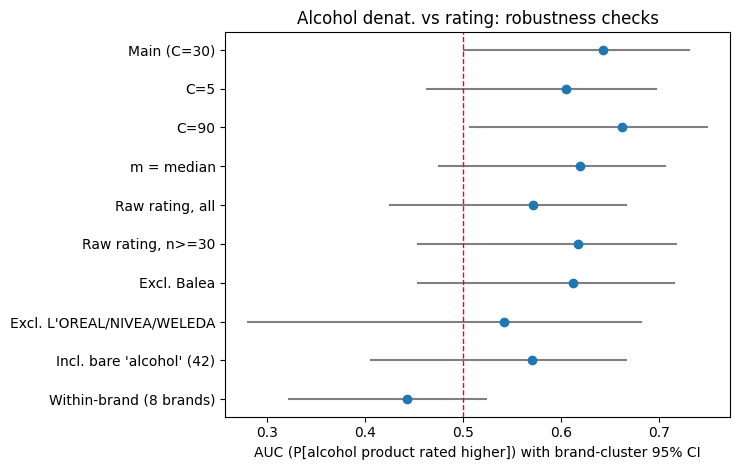

                        設定   AUC  CI_low  CI_high
               Main (C=30) 0.643   0.501    0.731
                       C=5 0.605   0.463    0.697
                      C=90 0.662   0.507    0.749
                m = median 0.619   0.476    0.706
           Raw rating, all 0.571   0.426    0.666
         Raw rating, n>=30 0.617   0.454    0.717
               Excl. Balea 0.612   0.454    0.715
Excl. L'OREAL/NIVEA/WELEDA 0.542   0.281    0.682
 Incl. bare 'alcohol' (42) 0.570   0.406    0.666
   Within-brand (8 brands) 0.443   0.323    0.524


In [ ]:
forest = [
    ("Main (C=30)",                pick(t_main, "アルコール あり/なし", "bayes")),
    ("C=5",                        pick(t_C, "アルコール あり/なし C=5")),
    ("C=90",                       pick(t_C, "アルコール あり/なし C=90")),
    ("m = median",                 pick(t_med, "アルコール あり/なし")),
    ("Raw rating, all",            pick(t_main, "アルコール あり/なし", "rating_value")),
    ("Raw rating, n>=30",          pick(t_ex, "n>=30: アルコール")),
    ("Excl. Balea",                pick(t_ex, "Balea除外: アルコール")),
    ("Excl. L'OREAL/NIVEA/WELEDA", pick(t_ex, "大手3除外: アルコール")),
    ("Incl. bare 'alcohol' (42)",  pick(t_alt, "アルコール(単独alcoholも含む)")),
    ("Within-brand (8 brands)",    pick(t_wb, "ブランド内: アルコール")),
]
fig, ax = plt.subplots(figsize=(7.5, 4.8))
for i, (lab, r) in enumerate(forest[::-1]):
    ax.plot([r["CI_low"], r["CI_high"]], [i, i], color="gray")
    ax.plot(r["AUC"], i, "o", color="C0")
ax.axvline(0.5, color="red", ls="--", lw=1)
ax.set_yticks(range(len(forest)))
ax.set_yticklabels([f[0] for f in forest[::-1]])
ax.set_xlabel("AUC (P[alcohol product rated higher]) with brand-cluster 95% CI")
ax.set_title("Alcohol denat. vs rating: robustness checks")
plt.tight_layout()
plt.savefig("alcohol_robustness_forest.png", dpi=150)
plt.show()

print(pd.DataFrame([{"設定": lab, "AUC": r["AUC"], "CI_low": r["CI_low"], "CI_high": r["CI_high"]} for lab, r in forest]).to_string(index=False))

### 図の読み方

- 赤い破線(AUC = 0.5)を**明確に右へ外れている線は1本もない**。最も右の C=90 でも下限は 0.507 で境界上。
- 点はほぼすべて 0.5 より右(0.54〜0.66)だが、これらは同じ167商品を少しずつ違う形で見ているだけで、独立な10回の確認ではない。
- 唯一、点が 0.5 より左なのがブランド内比較(0.443)だが、線は 0.5 を跨ぐ。「逆向き」ではなく「傾向が消えた」。

## 結論と限界

**香料**: 全設定で rating との関連は見えなかった。「差がない」ではなく「差があるという証拠は得られなかった」(CIが広い)。

**アルコール系溶媒**: 単純比較では高めだが、成分そのものの効果とは言えない。
- CI下限が 0.5 の境界上で、乱数・設定で上下する
- アルコール入り34件のうち29件が5ブランド(L'ORÉAL 11, WELEDA 6, NIVEA 5, lavera 4, GARNIER 3)に集中
- 大手3ブランドを除くと AUC 0.542、ブランド内比較では 0.443 で、傾向が消える
- 単独 `alcohol` を定義に足すだけで弱まる
- 「大手ブランドの商品が高評価・レビュー多数になりやすい」ことが最も自然な説明だが、このデータだけでは確定できない

**限界**
- 因果ではなく関連。「香料入りだから低評価」「アルコール入りだから高評価」とは言えない
- アルコール入りは34件、ブランド内比較は実質4ブランドで、検出力は低い(「効果がない」とは言えない)
- 多数の比較を行ったため、個々のp値は探索的に扱う
- `private_label` は167件中137件が欠損で交絡の確認に使えなかった

**方法論の知見**
1. ベイズ平均は縮小先 m の取り方で、レビュー数との人工的な相関を作る。このデータでは平均より中央値が適切だった
2. p値が小さくても、ブランド単位のCI・ブランド内比較で消えることがある
3. 成分フラグの検出ロジックを検証したことで、アルコール5件の取りこぼしが見つかった